# Lab 4: Statistics Intuition

## Objective

The objective of this lab is to develop an intuitive understanding of
statistical measures and use them to reason about the Wine Quality dataset.

Tasks performed:
1. Compute mean, median, standard deviation, and percentiles for a numerical column.
2. Analyze the distribution and identify skewness and potential outliers.
3. Compute a correlation matrix, identify the strongest pair, and interpret the relationship.
4. Form a simple hypothesis comparing two groups and perform an appropriate statistical test.

### Task 1 — Descriptive Statistics

#### Step 1.1: Import Required Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#### Step 1.2: Load the Dataset

In [15]:
df = pd.read_csv("data/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#### Step 1.3: Select the Numerical Column

The `alcohol` column is selected for descriptive statistical analysis.

In [8]:
alcohol = df["alcohol"]
alcohol.head()

0    9.4
1    9.8
2    9.8
3    9.8
4    9.4
Name: alcohol, dtype: float64

#### Step 1.4: Calculate Mean

In [6]:
mean_alcohol = df["alcohol"].mean()

print("Mean alcohol content:", mean_alcohol)

Mean alcohol content: 10.442111402741325


#### Step 1.5: Calculate Median

In [7]:
median_alcohol = df["alcohol"].median()

print("Median alcohol content:", median_alcohol)

Median alcohol content: 10.2


#### Step 1.6: Calculate Standard Deviation
Standard deviation (SD) tells you how spread out the data is from its mean (average)

In [8]:
std_alcohol = alcohol.std()

print("Standard deviation:", std_alcohol)

Standard deviation: 1.0821956098764445


#### Step 1.7: Calculate Percentiles

In [10]:
percentiles = alcohol.quantile([0.25, 0.50, 0.75])

print("Percentiles:")
print(percentiles)

Percentiles:
0.25     9.5
0.50    10.2
0.75    11.1
Name: alcohol, dtype: float64


#### Step 1.8: Compare Mean and Median

In [12]:
mean_median_difference = mean_alcohol - median_alcohol

print("Mean:", mean_alcohol)
print("Median:", median_alcohol)
print("Mean - Median:", mean_median_difference)

Mean: 10.442111402741325
Median: 10.2
Mean - Median: 0.24211140274132603


**What the gap means:** Since the mean is slightly higher than the median, a few wines have very high alcohol levels.
These high values increase the average, making the data slightly right-skewed..

### Task 2: Distribution, Skewness and Outliers

#### Step 2.1: Plot Distribution

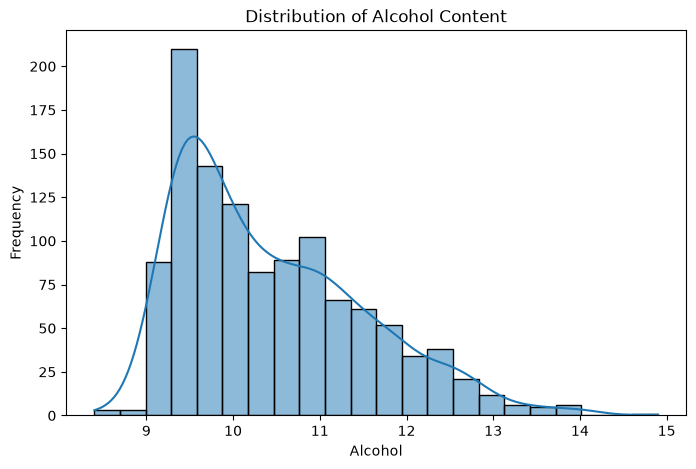

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(alcohol, kde=True)

plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

#### Observation

The histogram shows a right-skewed distribution, with most alcohol values
clustered in the middle range and a longer tail toward higher values.

#### Step 2.2: Calculate Skewness

In [16]:
skewness = alcohol.skew()

print("Skewness:", skewness)

Skewness: 0.8633132317223615


#### Step 2.3: Identify Outliers Using IQR

In [18]:
Q1 = alcohol.quantile(0.25)
Q3 = alcohol.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = alcohol[
    (alcohol < lower_bound) | (alcohol > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 9.5
Q3: 11.1
IQR: 1.5999999999999996
Lower bound: 7.1000000000000005
Upper bound: 13.5
Number of outliers: 12


#### Step 2.4: Visualize Outliers Using Boxplot

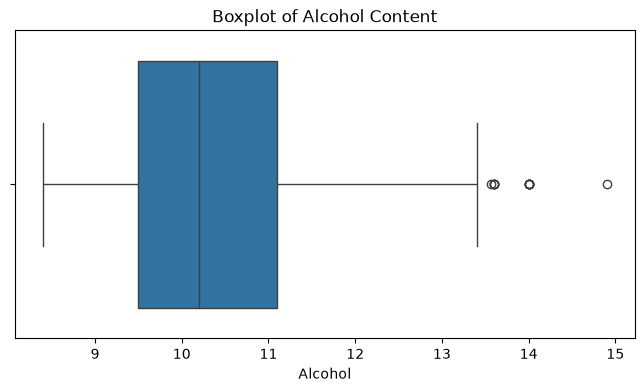

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=alcohol)

plt.title("Boxplot of Alcohol Content")
plt.xlabel("Alcohol")
plt.show()

#### Observation

The boxplot confirms several points beyond the upper whisker, matching the
outlier count from the IQR calculation — a handful of unusually
high-alcohol wines.

### Task 3: Correlation Analysis

#### Step 3.1: Compute Correlation Matrix
here ***include=np.number*** will take only the numberical columns

In [22]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


#### Step 3.4: Correlation Does Not Imply Causation

A strong correlation shows two variables tend to move together, but it does
not prove that one causes the other. A third factor could be driving both,
or the pattern could be specific to this sample.

### Task 4: Hypothesis Testing

#### Step 4.1: Define Two Groups

- Low-quality wines: `quality < 6`
- High-quality wines: `quality >= 6`

In [10]:
low_qualityy = df[df["quality"] < 6]["alcohol"]
high_qualityy = df[df["quality"] >= 6]["alcohol"]

print("Low-quality group size:", len(low_qualityy))
print("High-quality group size:", len(high_qualityy))

Low-quality group size: 522
High-quality group size: 621


#### Step 4.2: State the Hypotheses

- **Null Hypothesis (H₀):** The mean alcohol content is the same for both groups.
- **Alternative Hypothesis (H₁):** The mean alcohol content differs between the two groups.

#### Step 4.3: Calculate Group Means

In [11]:
print("Mean alcohol - Low quality:", low_qualityy.mean())
print("Mean alcohol - High quality:", high_qualityy.mean())

Mean alcohol - Low quality: 9.922509578544062
Mean alcohol - High quality: 10.878878153515833


In [18]:
t_statistic, p_value = stats.ttest_ind(
    low_qualityy,
    high_qualityy,
    equal_var=False
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: -17.067079800674428
p-value: 3.7124677991679516e-58


#### Step 4.4: What the p-value Does Not Tell You

The p-value does not measure how large or practically important the
difference is — it also does not prove that alcohol content causes higher
quality ratings.

Since the p-value is far below 0.05, the null hypothesis is rejected. There
is strong statistical evidence that mean alcohol content differs between the
two quality groups.

## Overall Observation

The analysis provided insights into the central tendency, variability,
distribution, outliers, and relationships among the wine quality variables.
The hypothesis test also helped determine whether the difference between the
two quality groups was statistically significant.